In [2]:
import pandas as pd
from pathlib import Path
RUTA_ACCIDENTES = Path("../Datos/Staging/accidentes_staging.csv")

accidentes = pd.read_csv(RUTA_ACCIDENTES, parse_dates=["TW"])

# Una fila por BARRIO + TW (evita duplicar filas de clima en el merge)
accidentes_target = (
    accidentes.groupby(["BARRIO", "TW"], as_index=False)
    .agg(
        n_accidentes=("GRAVEDAD", "size"),
        target=("GRAVEDAD", lambda _: 1),
    )
)

print(f"Accidentes (registros): {len(accidentes):,}")
print(f"Claves únicas BARRIO + TW: {len(accidentes_target):,}")
accidentes_target.head()

C:\Users\camil\AppData\Local\Temp\ipykernel_10476\264551052.py:5: DtypeWarning: Columns (0: RADICADO) have mixed types. Specify dtype option on import or set low_memory=False.
  accidentes = pd.read_csv(RUTA_ACCIDENTES, parse_dates=["TW"])


Accidentes (registros): 125,122
Claves únicas BARRIO + TW: 120,587


,BARRIO,TW,n_accidentes,target
0,aguasfrias,2017-02-05 22:00:00,1,1
1,aguasfrias,2017-02-25 23:00:00,1,1
2,aguasfrias,2017-03-04 23:00:00,1,1
3,aguasfrias,2017-06-02 17:00:00,1,1
4,aguasfrias,2017-06-11 13:00:00,1,1


In [3]:
import pandas as pd
from pathlib import Path

RUTA_CLIMA = Path("../Datos/Staging/clima_limpio.csv")

# Tipos ligeros: el CSV pesa ~750 MB; cargarlo de golpe suele dar "out of memory"
DTYPES = {
    "BARRIO": "category",
    "summary": "category",
    "precipIntensity": "float32",
    "precipProbability": "float32",
    "temperature": "float32",
    "dewPoint": "float32",
    "humidity": "float32",
    "windSpeed": "float32",
    "windBearing": "float32",
    "cloudCover": "float32",
    "uvIndex": "float32",
    "visibility": "float32",
}

COLUMNAS_SIN_NULOS = [
    "windSpeed",
    "cloudCover",
    "visibility",
    "uvIndex",
    "humidity",
    "temperature",
    "dewPoint",
]

CHUNK_SIZE = 500_000
partes = []

for i, chunk in enumerate(
    pd.read_csv(
        RUTA_CLIMA,
        chunksize=CHUNK_SIZE,
        parse_dates=["TW"],
        dtype=DTYPES,
    ),
    start=1,
):
    antes = len(chunk)
    chunk = chunk.dropna(subset=COLUMNAS_SIN_NULOS)
    partes.append(chunk)
    print(f"  Bloque {i}: {len(chunk):,} filas ({antes - len(chunk):,} con nulos eliminadas)")

clima = pd.concat(partes, ignore_index=True)
del partes

print(f"\nFilas: {len(clima):,}")
print(f"Memoria aprox.: {clima.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Columnas: {list(clima.columns)}")
clima.head()

  Bloque 1: 500,000 filas (0 con nulos eliminadas)
  Bloque 2: 500,000 filas (0 con nulos eliminadas)
  Bloque 3: 500,000 filas (0 con nulos eliminadas)
  Bloque 4: 500,000 filas (0 con nulos eliminadas)
  Bloque 5: 500,000 filas (0 con nulos eliminadas)
  Bloque 6: 500,000 filas (0 con nulos eliminadas)
  Bloque 7: 500,000 filas (0 con nulos eliminadas)
  Bloque 8: 500,000 filas (0 con nulos eliminadas)
  Bloque 9: 500,000 filas (0 con nulos eliminadas)
  Bloque 10: 500,000 filas (0 con nulos eliminadas)
  Bloque 11: 500,000 filas (0 con nulos eliminadas)
  Bloque 12: 500,000 filas (0 con nulos eliminadas)
  Bloque 13: 500,000 filas (0 con nulos eliminadas)
  Bloque 14: 500,000 filas (0 con nulos eliminadas)
  Bloque 15: 436,188 filas (0 con nulos eliminadas)

Filas: 7,436,188
Memoria aprox.: 1.27 GB
Columnas: ['TW', 'BARRIO', 'summary', 'precipIntensity', 'precipProbability', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility']


,TW,BARRIO,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,1.02,90.0,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


In [4]:
df_accidentes = accidentes_target.merge(
    clima,
    on=["BARRIO", "TW"],
    how="inner",
)
 
print(f"Claves con accidente: {len(accidentes_target):,}")
print(f"Filas tras inner join (con clima): {len(df_accidentes):,}")
print(f"Sin match en clima: {len(accidentes_target) - len(df_accidentes):,}")
print(f"\nColumnas: {df_accidentes.shape[1]} | target siempre 1, sin NaN en n_accidentes\n")
 
df_accidentes.head(10)

Claves con accidente: 120,587
Filas tras inner join (con clima): 112,575
Sin match en clima: 8,012

Columnas: 15 | target siempre 1, sin NaN en n_accidentes



,BARRIO,TW,n_accidentes,target,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,aguasfrias,2017-02-05 22:00:00,1,1,Mostly Cloudy,0.0000,0.0,19.430000,16.00,0.81,1.50,20.0,0.75,0.0,10.003
1,aguasfrias,2017-02-25 23:00:00,1,1,Mostly Cloudy,0.0000,0.0,18.430000,15.00,0.80,1.50,50.0,0.75,0.0,10.003
2,aguasfrias,2017-03-04 23:00:00,1,1,Partly Cloudy,0.0000,0.0,18.430000,14.00,0.75,3.10,341.0,0.44,0.0,8.998
3,aguasfrias,2017-06-02 17:00:00,1,1,Partly Cloudy,0.0000,0.0,23.959999,13.87,0.53,3.20,116.0,0.44,1.0,10.003
4,aguasfrias,2017-06-11 13:00:00,1,1,Mostly Cloudy,0.0000,0.0,26.059999,15.84,0.53,1.73,278.0,0.75,6.0,10.003
5,aguasfrias,2017-06-15 09:00:00,1,1,Overcast,0.0000,0.0,20.030001,13.81,0.67,0.00,90.0,0.99,3.0,9.912
6,aguasfrias,2017-07-15 15:00:00,1,1,Drizzle,0.1697,1.0,23.440001,12.02,0.49,1.34,261.0,0.44,5.0,10.003
7,aguasfrias,2017-08-21 19:00:00,1,1,Mostly Cloudy,0.0000,0.0,18.330000,9.99,0.58,2.08,113.0,0.75,0.0,10.003
8,aguasfrias,2017-08-23 10:00:00,1,1,Mostly Cloudy,0.0000,0.0,23.990000,13.17,0.51,0.74,182.0,0.75,6.0,10.003
9,aguasfrias,2017-08-30 06:00:00,1,1,Overcast,0.0000,0.0,15.040000,10.61,0.75,0.00,90.0,0.99,0.0,9.760


# EDA exploratorio — solo accidentes (target = 1)

Mismo análisis que `EDAclima.ipynb`, sobre `df_accidentes` (inner join).

In [8]:
import matplotlib.pyplot as plt

VARS_CLIMA = [
    "precipIntensity",
    "precipProbability",
    "temperature",
    "dewPoint",
    "humidity",
    "windSpeed",
    "windBearing",
    "cloudCover",
    "uvIndex",
    "visibility",
]

df = df_accidentes.copy()
print(f"Filas para EDA: {len(df):,}")
print(f"Columnas: {list(df.columns)}")
df.head()

Filas para EDA: 112,575
Columnas: ['BARRIO', 'TW', 'n_accidentes', 'target', 'summary', 'precipIntensity', 'precipProbability', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility']


,BARRIO,TW,n_accidentes,target,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,aguasfrias,2017-02-05 22:00:00,1,1,Mostly Cloudy,0.0,0.0,19.430000,16.00,0.81,1.50,20.0,0.75,0.0,10.003
1,aguasfrias,2017-02-25 23:00:00,1,1,Mostly Cloudy,0.0,0.0,18.430000,15.00,0.80,1.50,50.0,0.75,0.0,10.003
2,aguasfrias,2017-03-04 23:00:00,1,1,Partly Cloudy,0.0,0.0,18.430000,14.00,0.75,3.10,341.0,0.44,0.0,8.998
3,aguasfrias,2017-06-02 17:00:00,1,1,Partly Cloudy,0.0,0.0,23.959999,13.87,0.53,3.20,116.0,0.44,1.0,10.003
4,aguasfrias,2017-06-11 13:00:00,1,1,Mostly Cloudy,0.0,0.0,26.059999,15.84,0.53,1.73,278.0,0.75,6.0,10.003


In [6]:
nulos = df.isnull().sum()
porcentaje = (df.isnull().mean() * 100).round(4)
tabla_nulos = (
    pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje})
    .sort_values("Nulos", ascending=False)
)
print(f"Total filas: {len(df):,}")
print(f"Filas con al menos un nulo: {df.isnull().any(axis=1).sum():,}\n")
tabla_nulos


Total filas: 112,575
Filas con al menos un nulo: 0



,Nulos,Porcentaje (%)
BARRIO,0,0.0
TW,0,0.0
n_accidentes,0,0.0
target,0,0.0
summary,0,0.0
precipIntensity,0,0.0
precipProbability,0,0.0
temperature,0,0.0
dewPoint,0,0.0
humidity,0,0.0


## Distribución de variables numéricas

Para cada columna numérica: **histograma** (izquierda) y **boxplot** (derecha).

Se usa una muestra aleatoria de **100.000** filas para que los gráficos respondan bien.

In [9]:
import matplotlib.pyplot as plt

numericas = [c for c in VARS_CLIMA if c in df.columns]
muestra = df[numericas].sample(n=min(100_000, len(df)), random_state=42)

def graficar_hist_box(columnas, bins=50):
    """Una figura por variable: histograma | boxplot."""
    for col in columnas:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        datos = muestra[col].dropna()

        axes[0].hist(datos, bins=bins, edgecolor="black", color="steelblue")
        axes[0].set_title(f"Histograma de {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].ticklabel_format(style="plain", axis="y")

        axes[1].boxplot(datos, vert=True)
        axes[1].set_title(f"Boxplot de {col}")
        axes[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()


### Precipitación

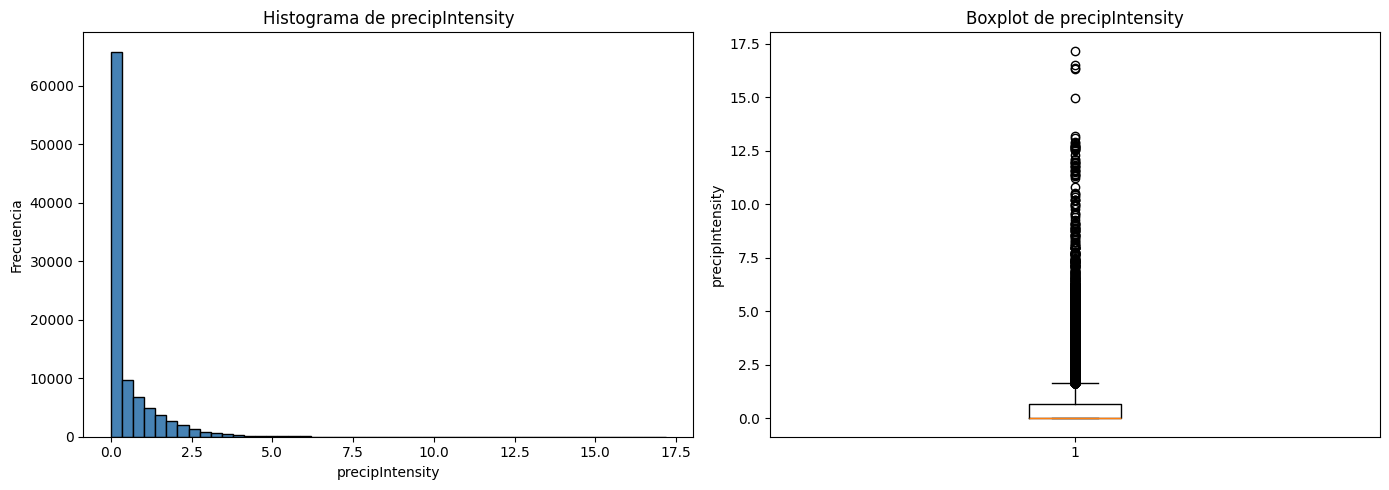

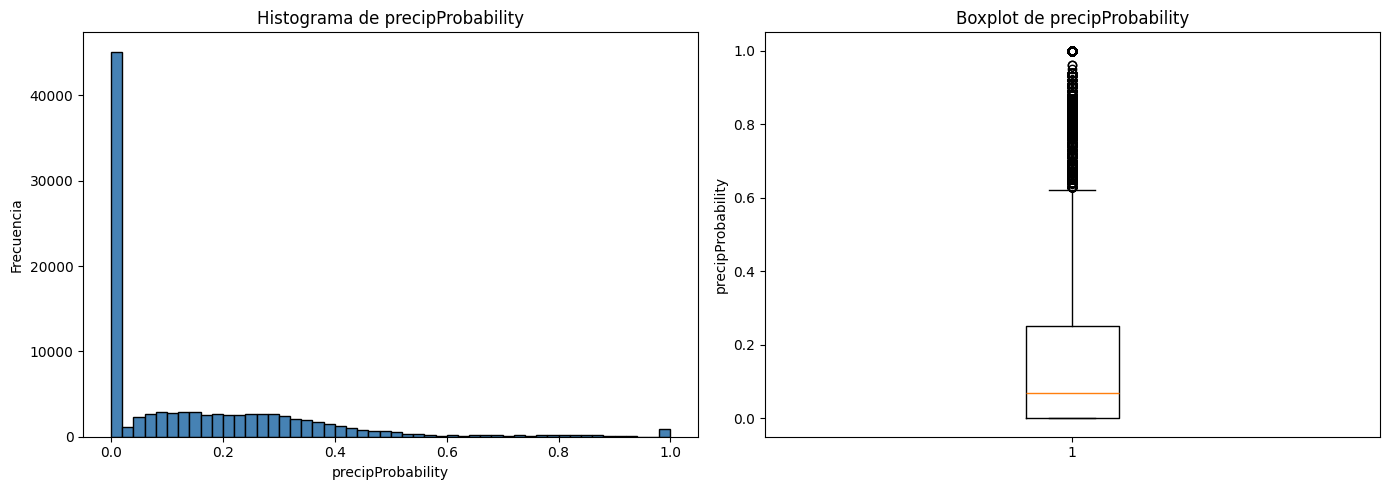

In [10]:
graficar_hist_box(["precipIntensity", "precipProbability"])

### Temperatura y humedad

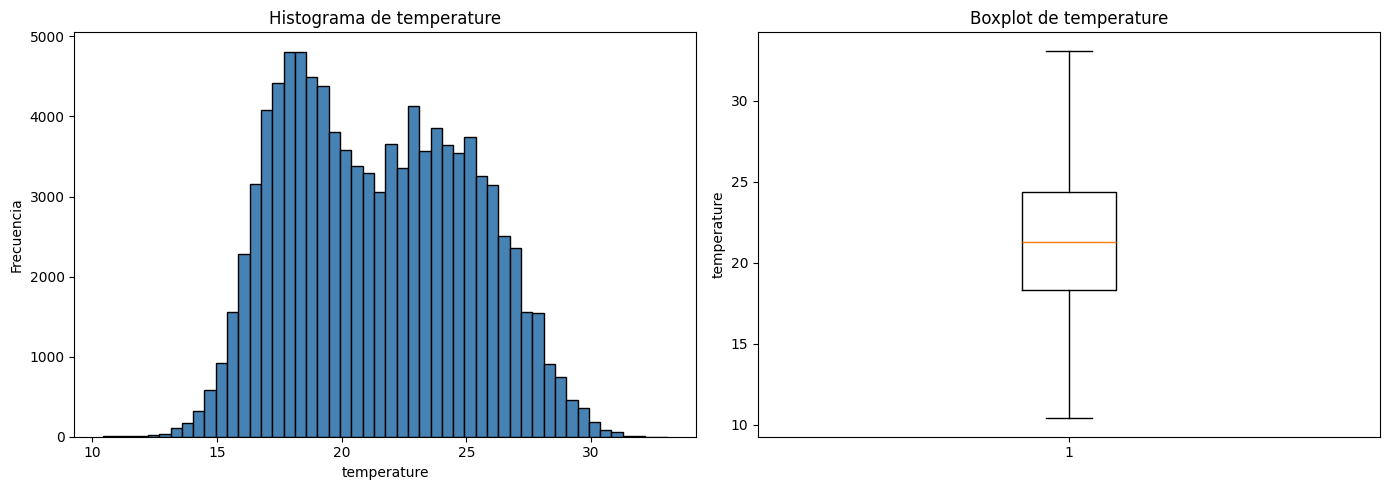

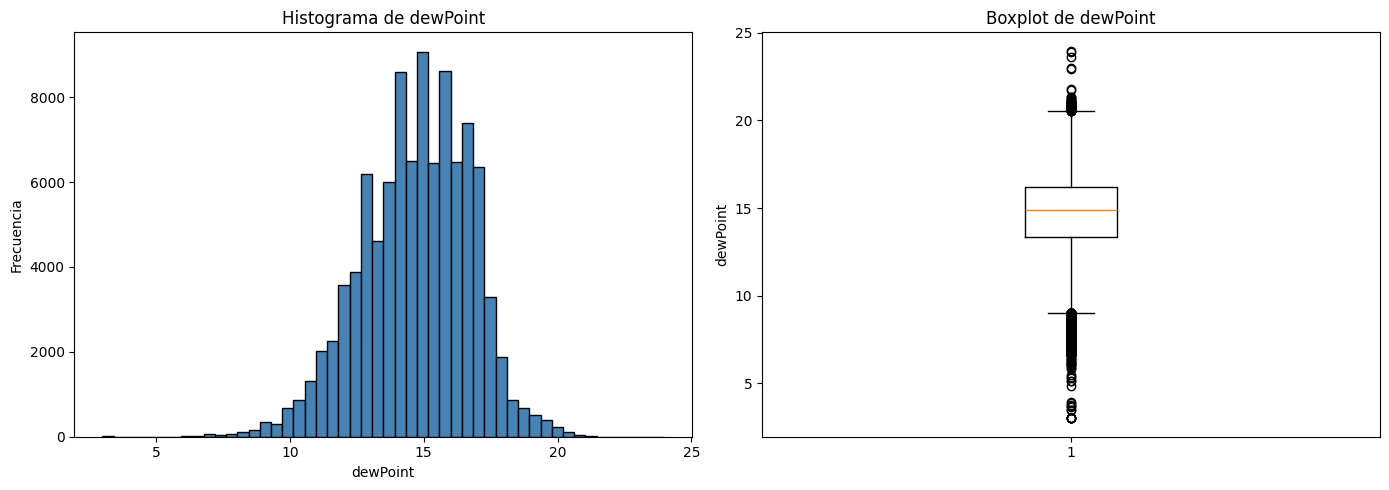

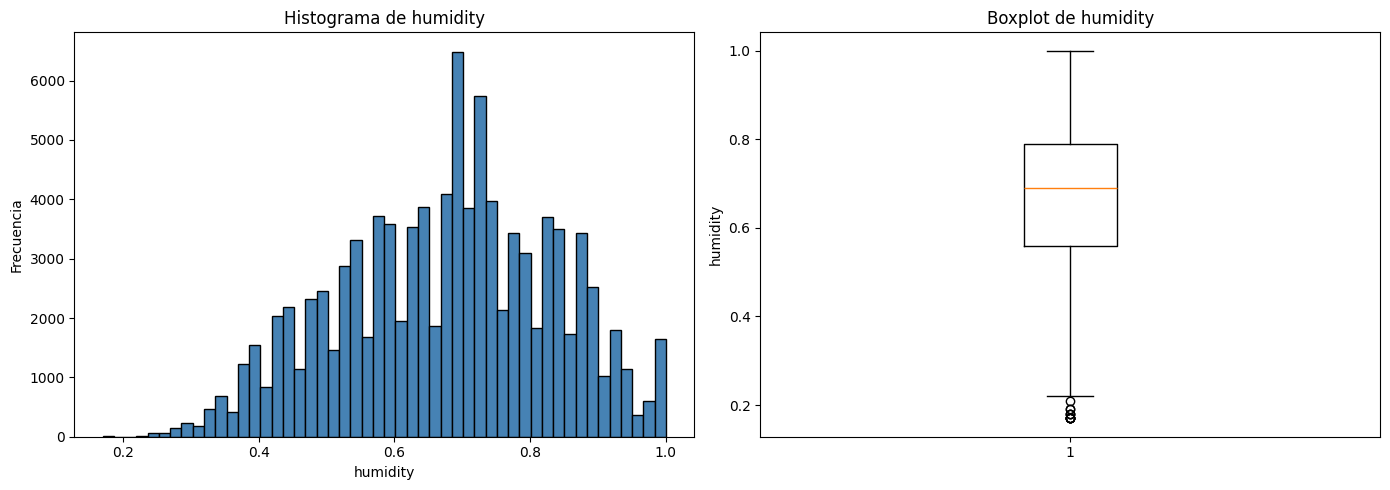

In [11]:
graficar_hist_box(["temperature", "dewPoint", "humidity"])

### Viento

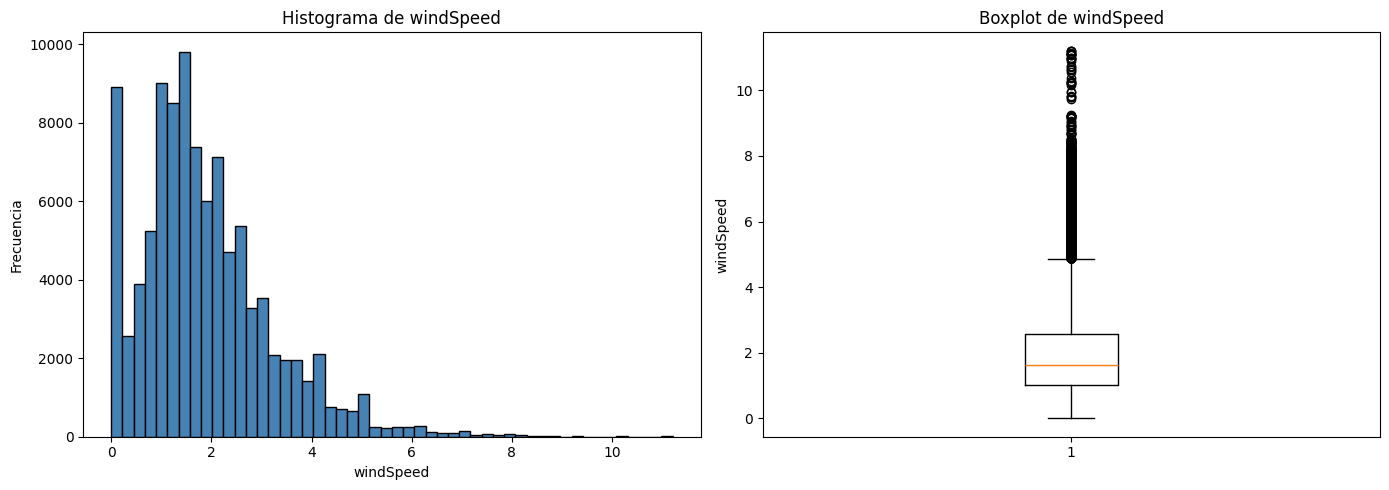

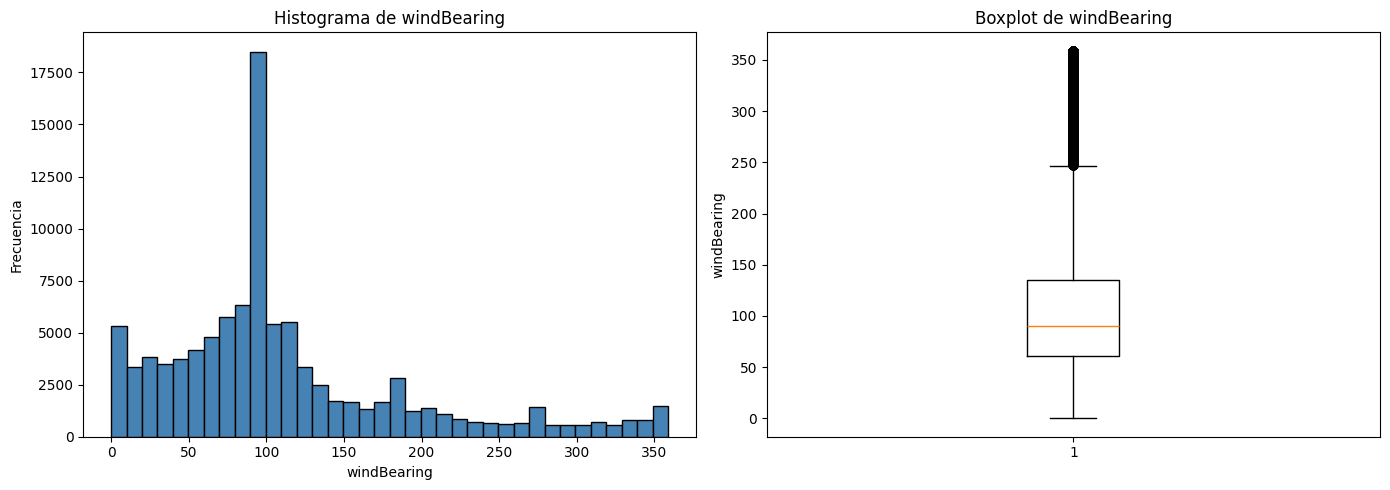

In [12]:
graficar_hist_box(["windSpeed"])
graficar_hist_box(["windBearing"], bins=36)

### Nubosidad, UV y visibilidad

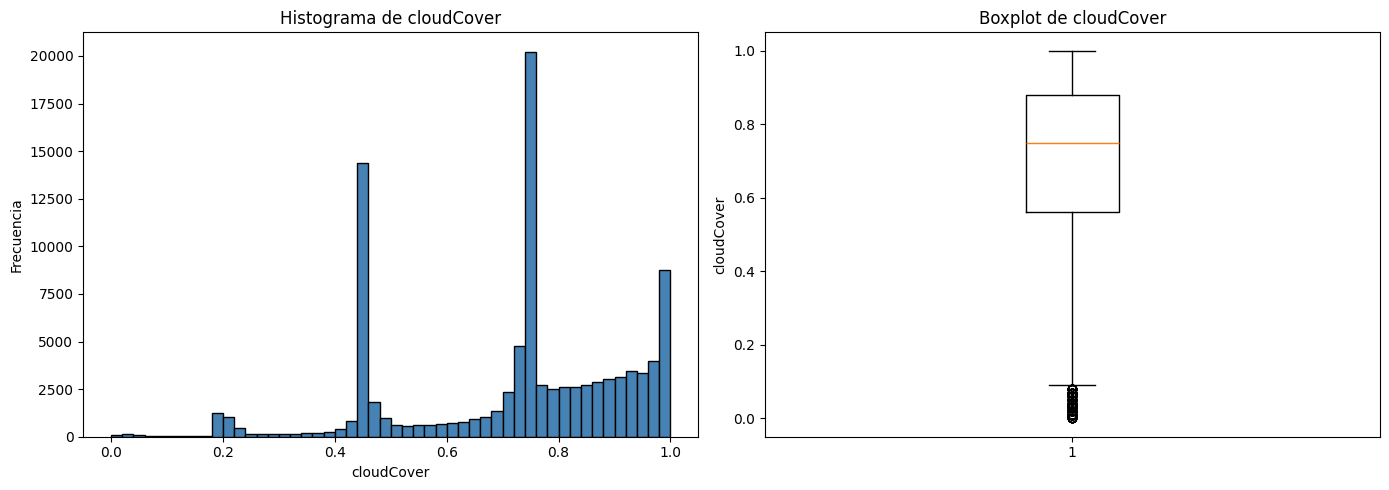

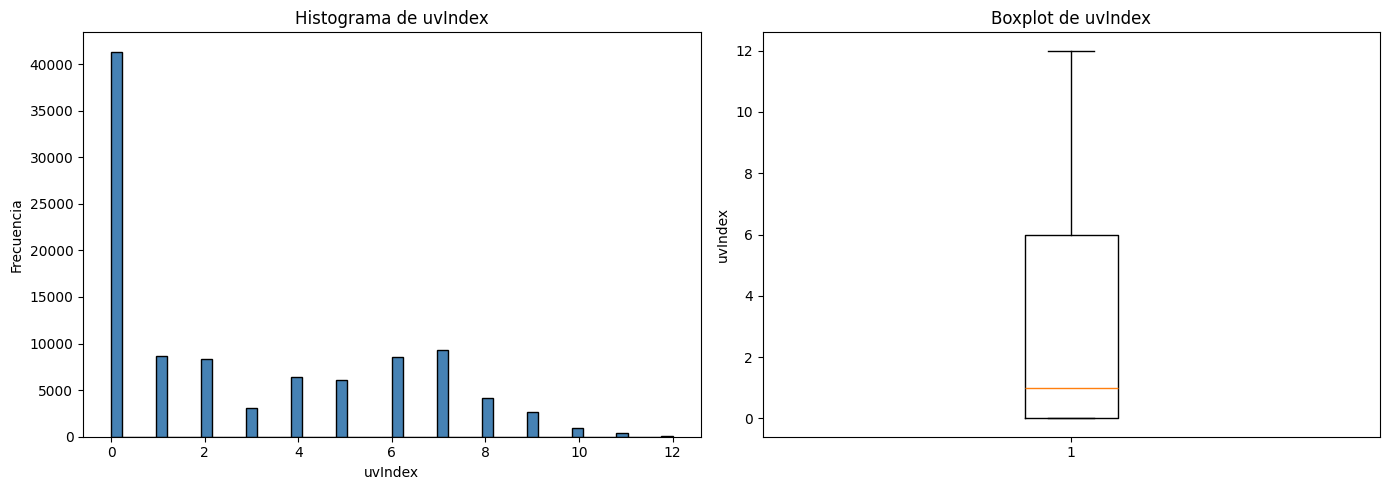

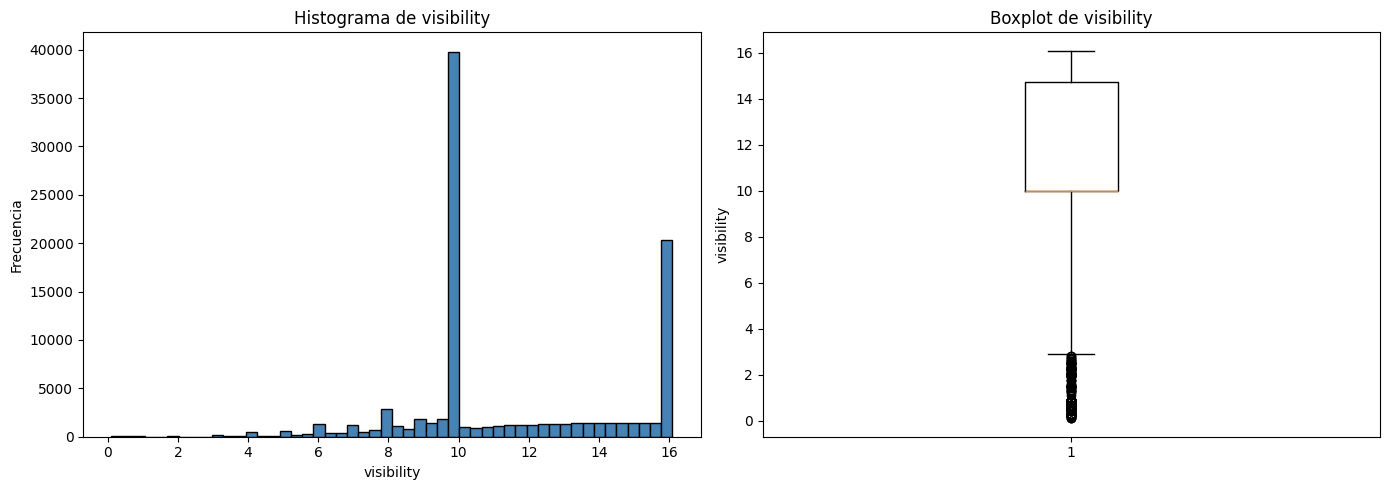

In [13]:
graficar_hist_box(["cloudCover", "uvIndex", "visibility"])

## Media, mediana y moda

Resumen de tendencia central de las variables climáticas en registros con accidente.

In [14]:
numericas = [c for c in VARS_CLIMA if c in df.columns]

def moda_serie(serie):
    valores = serie.mode()
    return valores.iloc[0] if len(valores) else float("nan")

estadisticas = pd.DataFrame({
    "Media": df[numericas].mean(),
    "Mediana": df[numericas].median(),
    "Moda": df[numericas].apply(moda_serie),
}).round(4)

print(f"Variables numéricas: {len(numericas)} | Filas: {len(df):,}\n")
estadisticas

Variables numéricas: 10 | Filas: 112,575



,Media,Mediana,Moda
precipIntensity,0.4960,0.0361,0.000
precipProbability,0.1474,0.0700,0.000
temperature,21.4564,21.2600,18.260
dewPoint,14.7152,14.8700,14.000
humidity,0.6762,0.6900,0.710
windSpeed,1.8828,1.6300,0.000
windBearing,110.7173,90.0000,90.000
cloudCover,0.7173,0.7500,0.750
uvIndex,2.7880,1.0000,0.000
visibility,11.5398,10.0030,10.003


## Varianza

Dispersión de cada variable climática en registros con accidente.

In [15]:
numericas = [c for c in VARS_CLIMA if c in df.columns]

varianza = df[numericas].var().round(4)
tabla_varianza = pd.DataFrame({"Varianza": varianza}).sort_values("Varianza", ascending=False)

print(f"Filas: {len(df):,}\n")
tabla_varianza

Filas: 112,575



,Varianza
windBearing,6508.955078
temperature,13.353800
visibility,9.550500
uvIndex,9.444000
dewPoint,4.157700
windSpeed,1.751800
precipIntensity,0.808400
cloudCover,0.042700
precipProbability,0.038800
humidity,0.024900


## Cuartiles

Cuartiles de cada variable numérica: **Q1** (25 %), **Q2** (mediana, 50 %) y **Q3** (75 %).

In [16]:
numericas = [c for c in VARS_CLIMA if c in df.columns]

cuartiles = df[numericas].quantile([0.25, 0.5, 0.75]).T
cuartiles.columns = ["Q1 (25%)", "Q2 / Mediana (50%)", "Q3 (75%)"]
cuartiles = cuartiles.round(4)

print(f"Filas: {len(df):,}\n")
cuartiles

Filas: 112,575



,Q1 (25%),Q2 / Mediana (50%),Q3 (75%)
precipIntensity,0.000,0.0361,0.6654
precipProbability,0.000,0.0700,0.2500
temperature,18.350,21.2600,24.4100
dewPoint,13.360,14.8700,16.2300
humidity,0.560,0.6900,0.8000
windSpeed,1.020,1.6300,2.5600
windBearing,61.000,90.0000,135.0000
cloudCover,0.560,0.7500,0.8800
uvIndex,0.000,1.0000,6.0000
visibility,10.003,10.0030,14.7515


## Desviación estándar

Mide la dispersión de cada variable numérica en las mismas unidades que la variable (a diferencia de la varianza, que está al cuadrado).

In [17]:
numericas = [c for c in VARS_CLIMA if c in df.columns]

desviacion = df[numericas].std().round(4)
tabla_std = pd.DataFrame({"Desviación estándar": desviacion}).sort_values(
    "Desviación estándar", ascending=False
)

print(f"Filas: {len(df):,}\n")
tabla_std

Filas: 112,575



,Desviación estándar
windBearing,80.678101
temperature,3.654300
visibility,3.090400
uvIndex,3.073100
dewPoint,2.039000
windSpeed,1.323600
precipIntensity,0.899100
cloudCover,0.206600
precipProbability,0.196900
humidity,0.157800


In [18]:
numericas = df[[c for c in VARS_CLIMA if c in df.columns]]

Q1 = numericas.quantile(0.25)
Q3 = numericas.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

out_inf = (numericas < lim_inf).sum()
out_sup = (numericas > lim_sup).sum()
total_out = out_inf + out_sup
porcentaje = (total_out / numericas.count() * 100).round(2)

resumen = pd.DataFrame({
    "Límite inferior": lim_inf.round(2),
    "Outliers (inf)": out_inf,
    "Límite superior": lim_sup.round(2),
    "Outliers (sup)": out_sup,
    "Total outliers": total_out,
    "Porcentaje (%)": porcentaje
}).sort_values("Total outliers", ascending=False)

resumen

,Límite inferior,Outliers (inf),Límite superior,Outliers (sup),Total outliers,Porcentaje (%)
precipIntensity,-1.00,0,1.66,10745,10745,9.54
windBearing,-50.00,0,246.00,10114,10114,8.98
precipProbability,-0.38,0,0.62,3833,3833,3.40
windSpeed,-1.29,0,4.87,3749,3749,3.33
dewPoint,9.05,766,20.53,97,863,0.77
cloudCover,0.08,401,1.36,0,401,0.36
visibility,2.88,347,21.87,0,347,0.31
humidity,0.20,14,1.16,0,14,0.01
temperature,9.26,0,33.50,0,0,0.00
uvIndex,-9.00,0,15.00,0,0,0.00


## Condición climática (`summary`) en accidentes

,summary,cantidad,porcentaje
0,Mostly Cloudy,42564,37.81%
1,Partly Cloudy,23185,20.60%
2,Possible Light Rain,18950,16.83%
3,Overcast,13813,12.27%
4,Clear,4228,3.76%
5,Rain,4226,3.75%
6,Possible Drizzle,1993,1.77%
7,Drizzle,1561,1.39%
8,Light Rain,1540,1.37%
9,Foggy,454,0.40%


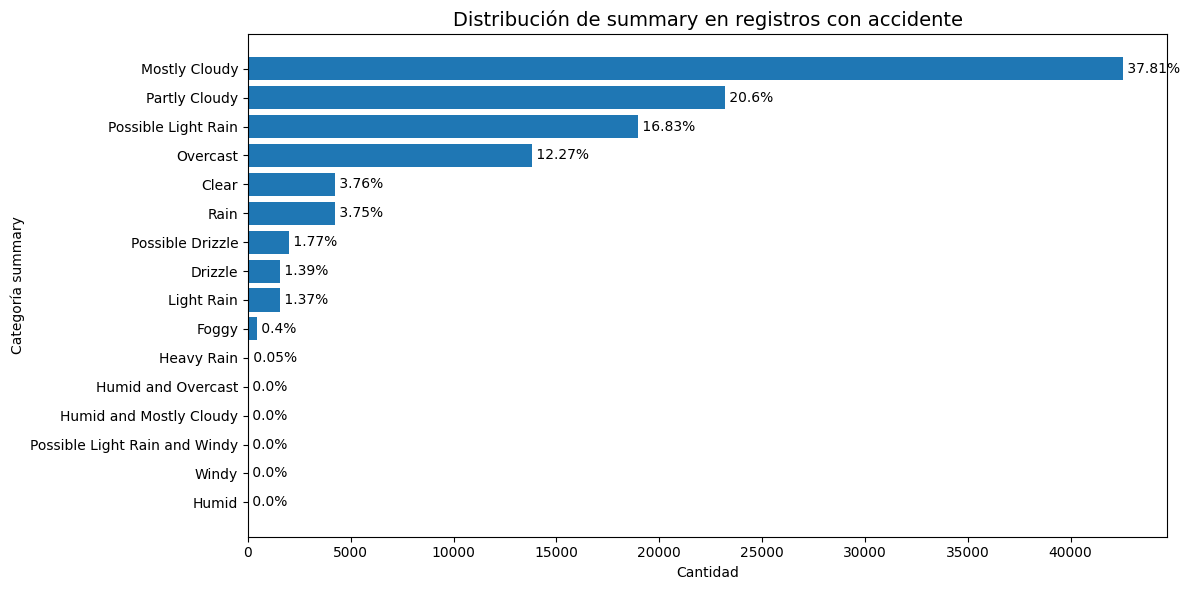

In [19]:
df_plot = df.copy()
df_plot['summary'] = df_plot['summary'].fillna('Sin dato')

dist_summary = df_plot['summary'].value_counts().reset_index()
dist_summary.columns = ['summary', 'cantidad']
dist_summary['porcentaje'] = (dist_summary['cantidad'] / dist_summary['cantidad'].sum() * 100).round(2)

tabla_mostrar = dist_summary.copy()
tabla_mostrar['porcentaje'] = tabla_mostrar['porcentaje'].map(lambda x: f'{x:.2f}%')
display(tabla_mostrar)

plt.figure(figsize=(12, 6))
plt.barh(dist_summary['summary'], dist_summary['cantidad'])
plt.gca().invert_yaxis()
plt.title('Distribución de summary en registros con accidente', fontsize=14)
plt.xlabel('Cantidad')
plt.ylabel('Categoría summary')
for i, row in dist_summary.iterrows():
    plt.text(row['cantidad'], i, f' {row["porcentaje"]}%', va='center')
plt.tight_layout()
plt.show()

## Distribución por rangos

Solo hay accidentes: se muestra el **% de registros** en cada rango (no tasa vs. horas sin accidente).

In [33]:
df["rango_temperatura"] = pd.qcut(df["temperature"], q=10, duplicates="drop")
dist_temp = df.groupby("rango_temperatura", observed=True).size().reset_index(name="cantidad")
dist_temp["porcentaje"] = (dist_temp["cantidad"] / len(df) * 100).round(2)
dist_temp

,rango_temperatura,cantidad,porcentaje
0,"(10.409, 16.87]",11324,10.06
1,"(16.87, 17.89]",11264,10.01
2,"(17.89, 18.84]",11189,9.94
3,"(18.84, 19.94]",11312,10.05
4,"(19.94, 21.26]",11243,9.99
5,"(21.26, 22.62]",11285,10.02
6,"(22.62, 23.81]",11202,9.95
7,"(23.81, 25.02]",11261,10.00
8,"(25.02, 26.43]",11275,10.02
9,"(26.43, 33.09]",11220,9.97


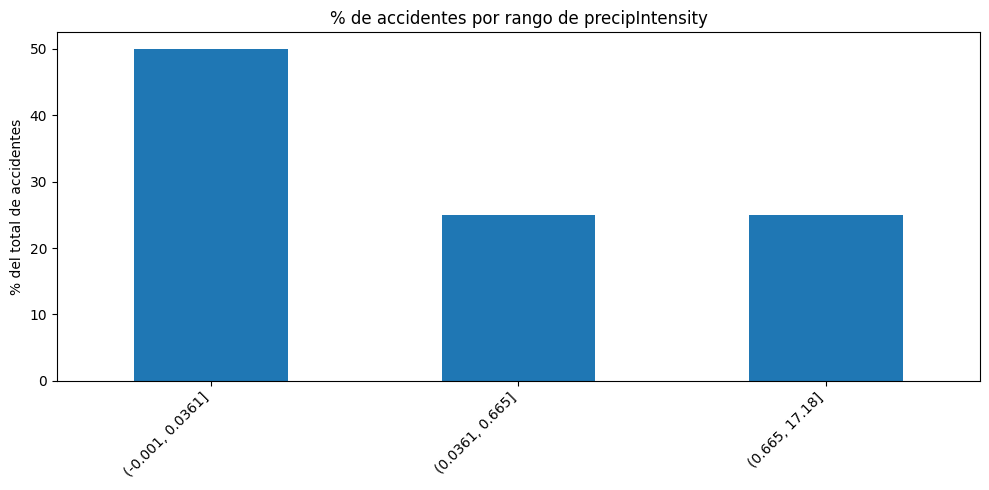

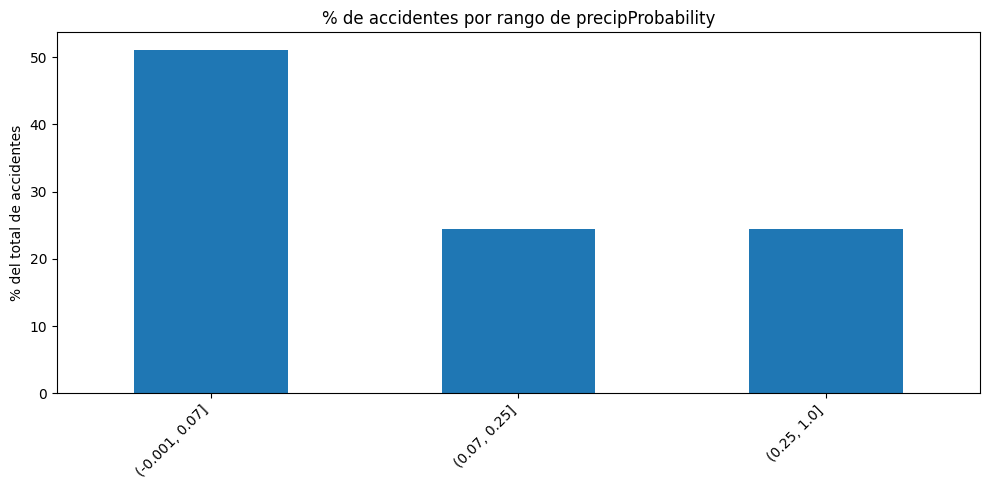

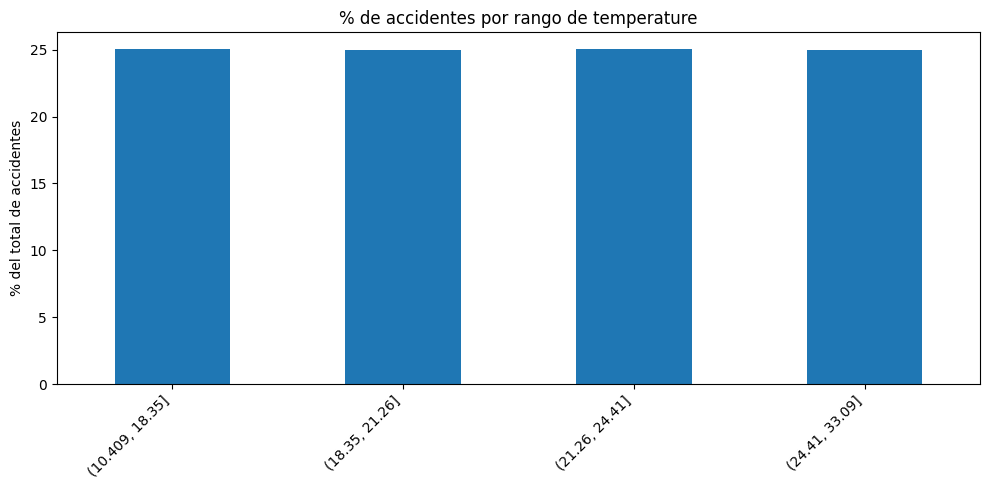

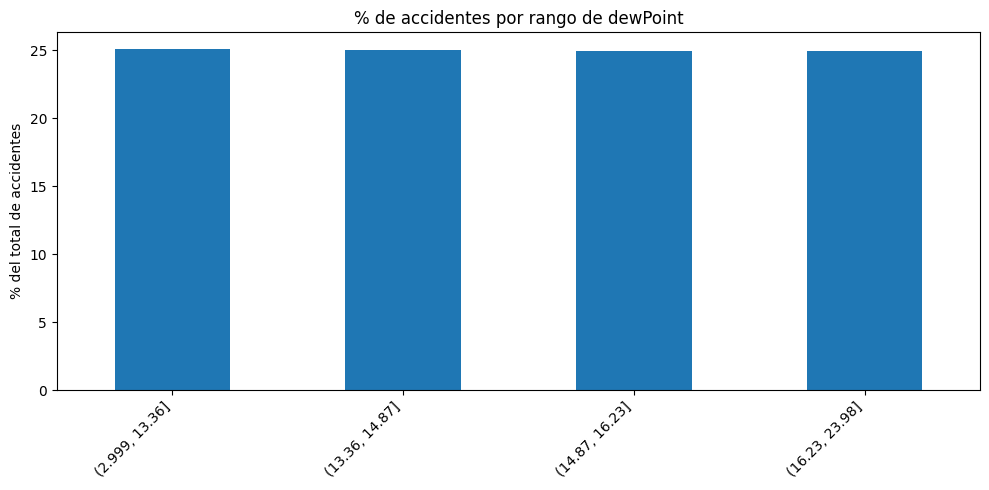

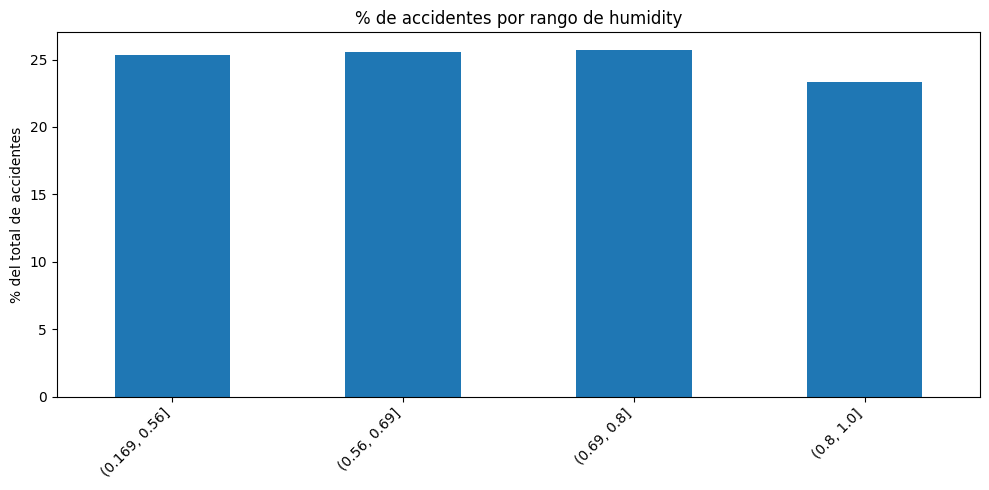

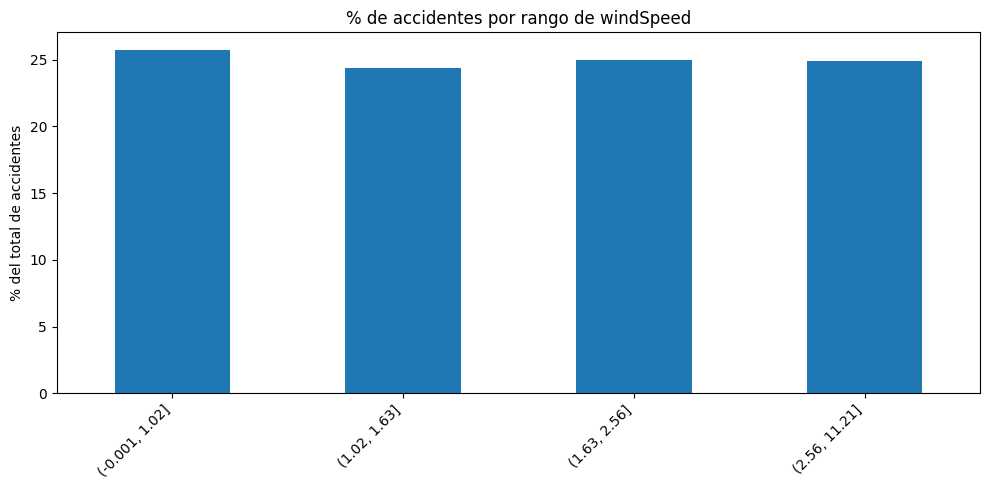

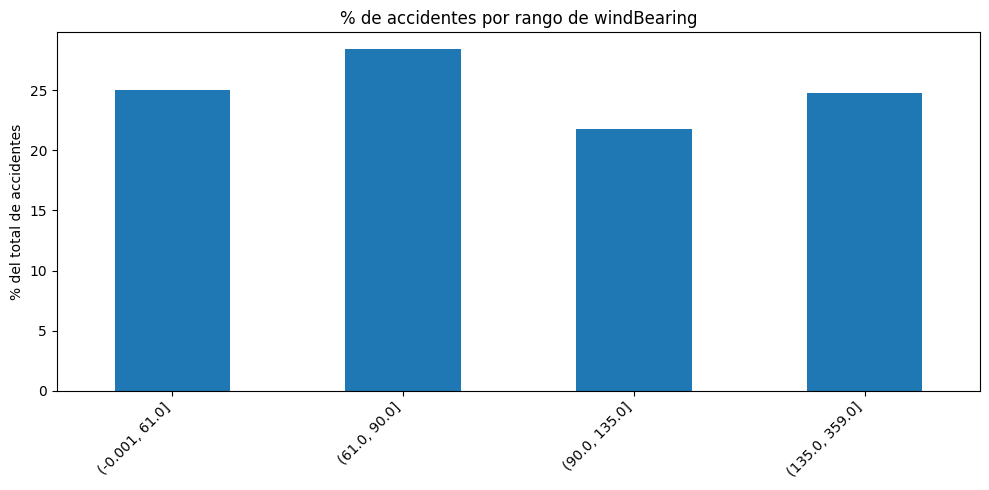

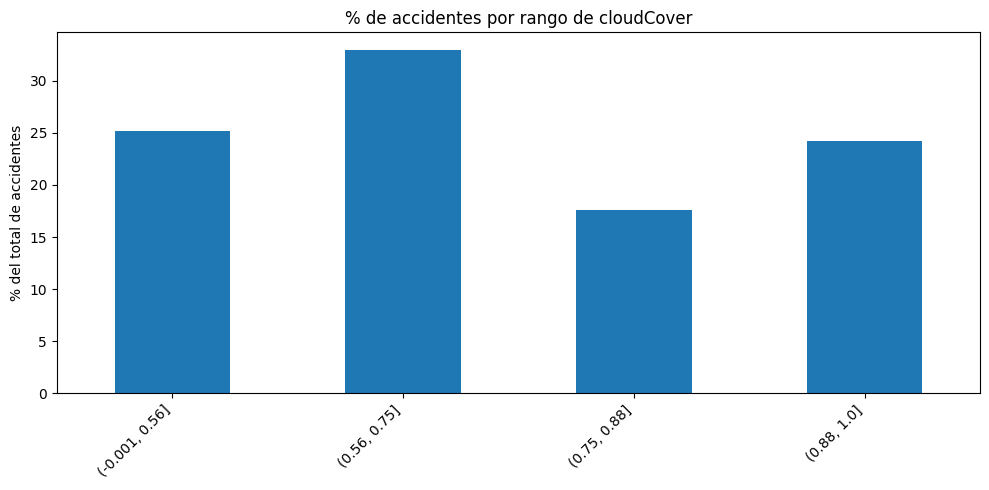

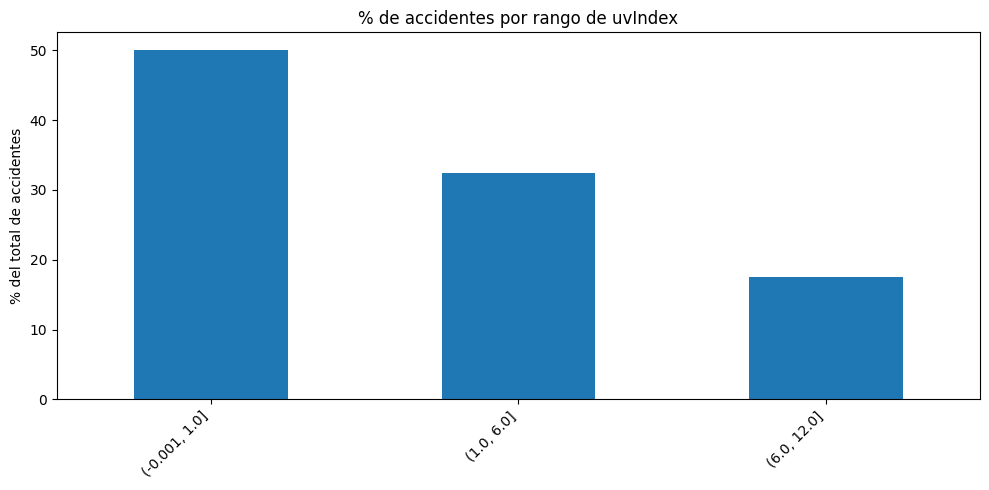

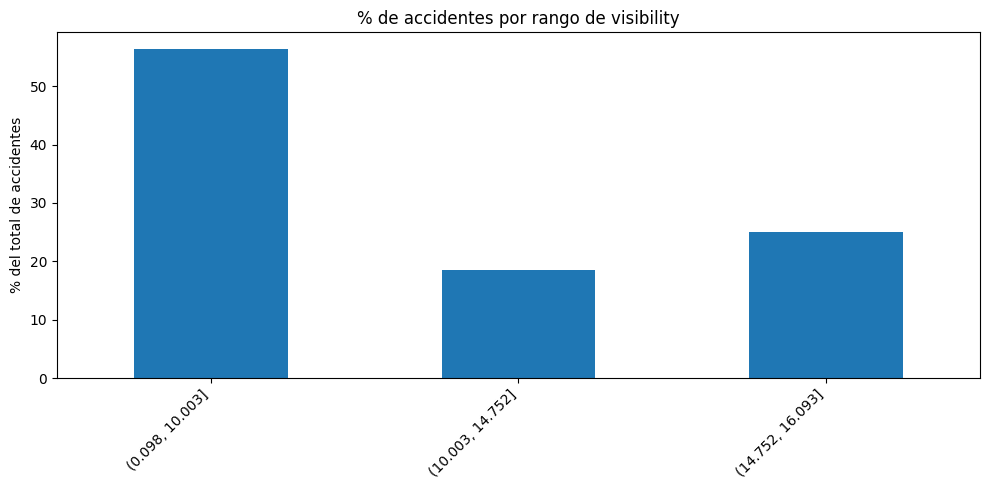

In [28]:
variables_clima = [c for c in VARS_CLIMA if c in df.columns]
for col in variables_clima:
    nueva_col = f"rango_{col}"
    df[nueva_col] = pd.qcut(df[col], q=4, duplicates="drop")
    dist = df.groupby(nueva_col, observed=True).size().reset_index(name="cantidad")
    dist["porcentaje"] = (dist["cantidad"] / len(df) * 100).round(2)
    ax = dist.plot(x=nueva_col, y="porcentaje", kind="bar", figsize=(10, 5), legend=False,
        title=f"% de accidentes por rango de {col}")
    ax.set_ylabel("% del total de accidentes")
    ax.set_xlabel("")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

## Lluvia en accidentes

,condicion,cantidad,porcentaje
0,Sin lluvia,50653,44.99
1,Con lluvia,61922,55.01


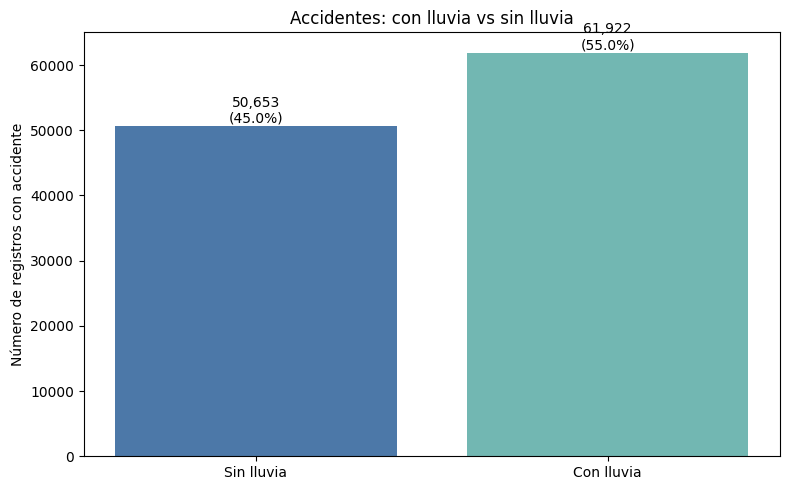

In [22]:
df["hay_lluvia"] = (df["precipIntensity"] > 0).astype(int)
tabla_lluvia = (
    df["hay_lluvia"].value_counts().sort_index()
    .rename({0: "Sin lluvia", 1: "Con lluvia"}).rename_axis("condicion").reset_index(name="cantidad")
)
tabla_lluvia["porcentaje"] = (tabla_lluvia["cantidad"] / len(df) * 100).round(2)
display(tabla_lluvia)
fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar(tabla_lluvia["condicion"], tabla_lluvia["cantidad"], color=["#4C78A8", "#72B7B2"])
ax.set_ylabel("Número de registros con accidente")
ax.set_title("Accidentes: con lluvia vs sin lluvia")
for bar, n, p in zip(barras, tabla_lluvia["cantidad"], tabla_lluvia["porcentaje"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{n:,}\n({p:.1f}%)", ha="center", va="bottom")
plt.tight_layout()
plt.show()